# Regression without `max_gfa` and `accommodation_value`

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

## Dataset

In [2]:
df = pd.read_csv("../data/transformation2.csv", header = 0)
df.head()

,adj_premium_per_sqm,latitude,longitude,FEDFUNDS,RGDP(Billions),in_als,sale_regime,n_tenderers,award_date,region
0,807.151900,22.275904,114.183839,5.45,162.655118,0,govt-led,4.0,1998-04-17,Hong Kong Island
1,1036.994510,22.504861,114.128737,5.45,162.655118,0,govt-led,4.0,1998-04-22,New Territories
2,2291.354912,22.283605,114.224674,5.49,162.655118,0,govt-led,4.0,1998-05-22,Hong Kong Island
3,452.522264,22.280948,114.228787,5.54,162.655118,0,govt-led,4.0,1998-07-15,Hong Kong Island
4,195.610425,22.306608,114.262269,5.07,162.655118,0,govt-led,4.0,1998-10-07,New Territories


### Preliminary Transformations

In [3]:
df = df.rename(columns={'RGDP(Billions)': 'RGDP'})
df['log_adj_premium_per_sqm'] = np.log(df['adj_premium_per_sqm'])
df['log_RGDP'] = np.log(df['RGDP'])
df['log_n_tenderers'] = np.log(df['n_tenderers'])

### Add New Dummy Variable

In [4]:
df['during_als'] = np.where(df['award_date'] < "2013-02-01", 1, 0)

In [5]:
df.head()

,adj_premium_per_sqm,latitude,longitude,FEDFUNDS,RGDP,in_als,sale_regime,n_tenderers,award_date,region,log_adj_premium_per_sqm,log_RGDP,log_n_tenderers,during_als
0,807.151900,22.275904,114.183839,5.45,162.655118,0,govt-led,4.0,1998-04-17,Hong Kong Island,6.693512,5.091632,1.386294,1
1,1036.994510,22.504861,114.128737,5.45,162.655118,0,govt-led,4.0,1998-04-22,New Territories,6.944082,5.091632,1.386294,1
2,2291.354912,22.283605,114.224674,5.49,162.655118,0,govt-led,4.0,1998-05-22,Hong Kong Island,7.736899,5.091632,1.386294,1
3,452.522264,22.280948,114.228787,5.54,162.655118,0,govt-led,4.0,1998-07-15,Hong Kong Island,6.114837,5.091632,1.386294,1
4,195.610425,22.306608,114.262269,5.07,162.655118,0,govt-led,4.0,1998-10-07,New Territories,5.276125,5.091632,1.386294,1


### Preliminary Datachecks

In [38]:
print(df['region'].unique())

<StringArray>
['Hong Kong Island', 'New Territories', 'Kowloon']
Length: 3, dtype: str


In [6]:
pd.crosstab(df['in_als'], df['sale_regime'])

sale_regime,ALS,govt-led
in_als,,
0,0,140
1,40,69


In [7]:
pd.crosstab(df['during_als'], df['sale_regime'])

sale_regime,ALS,govt-led
during_als,,
0,0,132
1,40,77


In [8]:
pd.crosstab(df['in_als'], df['during_als'])

during_als,0,1
in_als,,
0,107,33
1,25,84


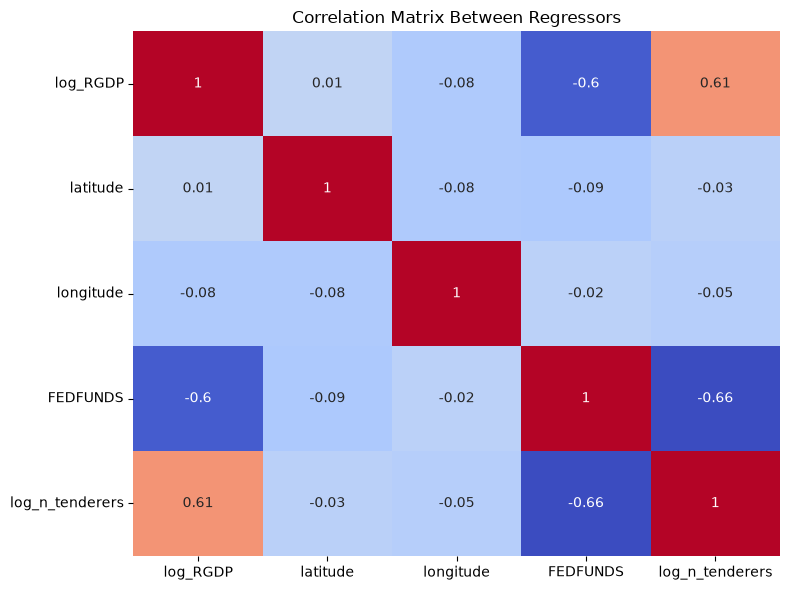

In [9]:
var_corr = ['log_RGDP', 'latitude', 'longitude', 'FEDFUNDS', 'log_n_tenderers']
corr = df[var_corr].corr().round(2)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    cbar=False
)
plt.title("Correlation Matrix Between Regressors")
plt.tight_layout()
plt.show()

## Regressions

In [24]:
model1 = smf.ols(
    """
    log_adj_premium_per_sqm ~ 
    latitude
    + longitude
    + FEDFUNDS
    + log_RGDP
    + sale_regime
    + in_als
    + during_als
    + log_n_tenderers
    + region
    """,
    data = df
).fit()

print(model1.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.629
Model:                                 OLS   Adj. R-squared:                  0.613
Method:                      Least Squares   F-statistic:                     40.35
Date:                     Fri, 28 Aug 2026   Prob (F-statistic):           8.23e-46
Time:                             09:33:20   Log-Likelihood:                -283.07
No. Observations:                      249   AIC:                             588.1
Df Residuals:                          238   BIC:                             626.8
Df Model:                               10                                         
Covariance Type:                 nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [25]:
model2 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + RGDP
    + FEDFUNDS
    + sale_regime
    + in_als
    + during_als
    + n_tenderers
    + region
    """, data= df
).fit()

print(model2.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.628
Model:                             OLS   Adj. R-squared:                  0.612
Method:                  Least Squares   F-statistic:                     40.18
Date:                 Fri, 28 Aug 2026   Prob (F-statistic):           1.13e-45
Time:                         09:33:20   Log-Likelihood:                -2177.0
No. Observations:                  249   AIC:                             4376.
Df Residuals:                      238   BIC:                             4415.
Df Model:                           10                                         
Covariance Type:             nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept   

### Interaction Regressions

#### Log Response

In [26]:
model3 = smf.ols(
    """
    log_adj_premium_per_sqm ~
    latitude
    + longitude
    + sale_regime
    + during_als
    + log_RGDP
    + FEDFUNDS
    + log_n_tenderers
    + region
    + in_als
    + in_als: during_als
    + in_als: sale_regime
    + in_als: log_RGDP
    + in_als: FEDFUNDS
    + in_als: log_n_tenderers
    """, data=df
).fit()

print(model3.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.647
Model:                                 OLS   Adj. R-squared:                  0.626
Method:                      Least Squares   F-statistic:                     30.63
Date:                     Fri, 28 Aug 2026   Prob (F-statistic):           4.00e-45
Time:                             09:33:20   Log-Likelihood:                -276.89
No. Observations:                      249   AIC:                             583.8
Df Residuals:                          234   BIC:                             636.6
Df Model:                               14                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [27]:
model4 = smf.ols(
    """
    log_adj_premium_per_sqm ~
    latitude
    + longitude
    + sale_regime
    + log_RGDP
    + FEDFUNDS
    + region
    + log_n_tenderers
    + in_als: sale_regime
    + in_als: during_als
    + in_als: log_RGDP
    + in_als: FEDFUNDS
    + in_als: log_n_tenderers
    """, data=df
).fit()

print(model4.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.644
Model:                                 OLS   Adj. R-squared:                  0.624
Method:                      Least Squares   F-statistic:                     32.69
Date:                     Fri, 28 Aug 2026   Prob (F-statistic):           1.81e-45
Time:                             09:33:20   Log-Likelihood:                -277.96
No. Observations:                      249   AIC:                             583.9
Df Residuals:                          235   BIC:                             633.2
Df Model:                               13                                         
Covariance Type:                 nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [28]:
model5 = smf.ols(
    """
    log_adj_premium_per_sqm ~
    latitude
    + longitude
    + log_RGDP
    + FEDFUNDS
    + log_n_tenderers
    + in_als
    + region
    + in_als: sale_regime
    + in_als: during_als
    + in_als: log_RGDP
    + in_als: FEDFUNDS
    + in_als: log_n_tenderers
    """, data=df
).fit()

print(model5.summary())

                               OLS Regression Results                              
Dep. Variable:     log_adj_premium_per_sqm   R-squared:                       0.644
Model:                                 OLS   Adj. R-squared:                  0.624
Method:                      Least Squares   F-statistic:                     32.69
Date:                     Fri, 28 Aug 2026   Prob (F-statistic):           1.81e-45
Time:                             09:33:20   Log-Likelihood:                -277.96
No. Observations:                      249   AIC:                             583.9
Df Residuals:                          235   BIC:                             633.2
Df Model:                               13                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [46]:
table = summary_col(
    [model1, model3, model4, model5],
    stars=True,
    float_format='%0.3f',
    model_names=['model1', 'model3', 'model4', 'model5'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                                  model1      model3      model4      model5  
------------------------------------------------------------------------------
Intercept                      -412.920*** -319.883*** -274.143*** -412.985***
                               (64.942)    (48.660)    (42.841)    (64.167)   
sale_regime[T.govt-led]        -0.497**    -110.814*** -138.843***            
                               (0.235)     (16.935)    (21.735)               
region[T.Kowloon]              -0.461***   -0.543***   -0.516***   -0.516***  
                               (0.176)     (0.177)     (0.177)     (0.177)    
region[T.New Territories]      -1.959***   -1.991***   -1.963***   -1.963***  
                               (0.189)     (0.188)     (0.187)     (0.187)    
latitude                       3.925***    3.922***    3.820***    3.820***   
                               (0.894)     (0.885)     (0.884)     (0.884)    
longitude                      2.783***    2.864***

#### Level Response

In [29]:
model6 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + sale_regime
    + during_als
    + RGDP
    + FEDFUNDS
    + log_n_tenderers
    + in_als
    + region
    + in_als: sale_regime
    + in_als: during_als
    + in_als: RGDP
    + in_als: FEDFUNDS
    + in_als: n_tenderers
    """, data=df
).fit()

print(model6.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.640
Model:                             OLS   Adj. R-squared:                  0.618
Method:                  Least Squares   F-statistic:                     29.69
Date:                 Fri, 28 Aug 2026   Prob (F-statistic):           3.92e-44
Time:                         09:33:20   Log-Likelihood:                -2173.0
No. Observations:                  249   AIC:                             4376.
Df Residuals:                      234   BIC:                             4429.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
In

In [30]:
model7 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + sale_regime
    + RGDP
    + during_als
    + FEDFUNDS
    + log_n_tenderers
    + region
    + in_als: sale_regime
    + in_als: during_als
    + in_als: RGDP
    + in_als: FEDFUNDS
    + in_als: n_tenderers
    """, data=df
).fit()

print(model7.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.640
Model:                             OLS   Adj. R-squared:                  0.618
Method:                  Least Squares   F-statistic:                     29.69
Date:                 Fri, 28 Aug 2026   Prob (F-statistic):           3.92e-44
Time:                         09:33:20   Log-Likelihood:                -2173.0
No. Observations:                  249   AIC:                             4376.
Df Residuals:                      234   BIC:                             4429.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Interc

In [31]:
model8 = smf.ols(
    """
    adj_premium_per_sqm ~
    latitude
    + longitude
    + RGDP
    + FEDFUNDS
    + during_als
    + n_tenderers
    + in_als
    + region
    + in_als: during_als
    + in_als: sale_regime
    + in_als: RGDP
    + in_als: FEDFUNDS
    + in_als: n_tenderers
    """, data=df
).fit()

print(model8.summary())

                             OLS Regression Results                            
Dep. Variable:     adj_premium_per_sqm   R-squared:                       0.642
Model:                             OLS   Adj. R-squared:                  0.621
Method:                  Least Squares   F-statistic:                     30.02
Date:                 Fri, 28 Aug 2026   Prob (F-statistic):           1.76e-44
Time:                         09:33:20   Log-Likelihood:                -2172.1
No. Observations:                  249   AIC:                             4374.
Df Residuals:                      234   BIC:                             4427.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
In

## Side Interesting Observations

In [39]:
model_n = smf.ols(
    """
    n_tenderers ~
    RGDP 
    + FEDFUNDS
    + in_als
    + sale_regime
    + latitude 
    + longitude
    + region
    """, data = df
).fit()

print(model_n.summary())

                            OLS Regression Results                            
Dep. Variable:            n_tenderers   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     61.88
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           4.33e-54
Time:                        09:36:25   Log-Likelihood:                -832.16
No. Observations:                 249   AIC:                             1682.
Df Residuals:                     240   BIC:                             1714.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [40]:
model_n2 = smf.ols(
    """
    n_tenderers ~
    RGDP 
    + FEDFUNDS
    + in_als
    + during_als
    + sale_regime
    + latitude 
    + longitude
    + region
    """, data = df
).fit()

print(model_n2.summary())

                            OLS Regression Results                            
Dep. Variable:            n_tenderers   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     64.00
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.11e-58
Time:                        09:36:57   Log-Likelihood:                -818.78
No. Observations:                 249   AIC:                             1658.
Df Residuals:                     239   BIC:                             1693.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [42]:
model_n3 = smf.ols(
    """
    n_tenderers ~
    RGDP 
    + FEDFUNDS
    + during_als
    + sale_regime
    + latitude 
    + longitude
    + region
    """, data = df
).fit()

print(model_n3.summary())

                            OLS Regression Results                            
Dep. Variable:            n_tenderers   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     42.61
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           5.40e-42
Time:                        09:37:17   Log-Likelihood:                -861.47
No. Observations:                 249   AIC:                             1741.
Df Residuals:                     240   BIC:                             1773.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [43]:
model_n4 = smf.ols(
    """
    n_tenderers ~
    RGDP 
    + FEDFUNDS
    + sale_regime
    + latitude 
    + longitude
    + region
    """, data = df
).fit()

print(model_n4.summary())

                            OLS Regression Results                            
Dep. Variable:            n_tenderers   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.575
Method:                 Least Squares   F-statistic:                     48.89
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           7.42e-43
Time:                        09:37:32   Log-Likelihood:                -861.47
No. Observations:                 249   AIC:                             1739.
Df Residuals:                     241   BIC:                             1767.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [44]:
table = summary_col(
    [model_n4, model_n, model_n3, model_n2],
    stars=True,
    float_format='%0.3f',
    model_names=['Baseline', 'With in_als', 'With during_als', 'With Both'],
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R²': lambda x: f"{x.rsquared:.3f}",
        'Adj. R²': lambda x: f"{x.rsquared_adj:.3f}"
    }
)

print(table)


                           Baseline  With in_als With during_als With Both 
---------------------------------------------------------------------------
Intercept                 -107.195   101.432     -107.989        67.025    
                          (655.250)  (584.262)   (656.982)       (554.912) 
sale_regime[T.govt-led]   10.745***  17.837***   10.720***       16.986*** 
                          (1.443)    (1.563)     (1.601)         (1.493)   
region[T.Kowloon]         2.666      3.274**     2.664           3.270**   
                          (1.785)    (1.592)     (1.790)         (1.512)   
region[T.New Territories] 5.819***   4.522***    5.827***        5.137***  
                          (1.896)    (1.697)     (1.912)         (1.616)   
RGDP                      0.021*     0.044***    0.020           -0.014    
                          (0.012)    (0.011)     (0.018)         (0.016)   
FEDFUNDS                  -3.136***  -2.009***   -3.138***       -1.962*** 
           

In [37]:
model_n5 = smf.ols(
    """
    log_n_tenderers ~
    log_RGDP 
    + FEDFUNDS
    + in_als
    + during_als
    + sale_regime
    + latitude 
    + longitude
    """, data = df
).fit()

print(model_n5.summary())

                            OLS Regression Results                            
Dep. Variable:        log_n_tenderers   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     104.1
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           3.36e-69
Time:                        09:33:20   Log-Likelihood:                -195.01
No. Observations:                 249   AIC:                             406.0
Df Residuals:                     241   BIC:                             434.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 